# 7 · Finální evaluace na sadě DS1

**Odpovídá sekci 5.1 práce — Výsledky na testovací sadě DS1**
(Tabulky 5.1 a 5.2, Obrázky 5.1–5.6).

Notebook ověřuje výkon kaskádové architektury navržené v notebocích `02`–`06`
na sadě **DS1 — 573 reálných faktur od 19 dodavatelů**, kterou systém neviděl
v žádné fázi vývoje.

> **Held-out sada.** Data DS1 nebyla použita při ladění promptů, výběru modelu ani
> nastavení akceptační kontroly. Veškerá konfigurace vychází výhradně z výsledků
> na vývojové sadě DS2. Jakékoli doladění podle výsledků DS1 by tuto sadu
> znehodnotilo jako nezávislý benchmark.

## Vyhodnocovaná konfigurace

| Krok | Nastavení | Zdroj rozhodnutí |
|---|---|---|
| Předzpracování | stupně šedi + potlačení šumu (P4) | notebook `02` |
| OCR | Tesseract 5.4, výstup ve formátu JSON-light | notebook `03` |
| Hlavní model | GPT‑4.1, few-shot, hybridní prompt `cs_en` | notebooky `04`, `05` |
| Záložní model | `gpt-4.1-mini` (Vision), zero-shot + RAG | notebook `06` |
| Přepínání | akceptační kontrola výstupu hlavní cesty | notebook `06` |

### Skórovací konvence

* **`null == 0`** — chybí-li v predikci hodnota a referenční hodnota je číselná
  nula, počítá se pole jako správně; položka na faktuře fyzicky není.
* **Bez dopočtu DPH** — pole `amount_inc_vat` se hodnotí proti syrové extrakci.
  Deterministický dopočet z základu daně a sazby byl z pipeline vyřazen, protože
  přesnost empiricky snižoval (0,575 → 0,537).

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

KOREN = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(KOREN / "experiments"))

from thesis_style import *          # noqa: F403
pouzij_styl()

DATA = KOREN / "experiments" / "data"
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print("Data:", DATA.relative_to(KOREN))

Data: experiments\data


In [2]:
faktury = pd.read_csv(DATA / "07_evaluace_ds1" / "ds1_per_invoice.csv")
pole = pd.read_csv(DATA / "07_evaluace_ds1" / "ds1_per_field.csv")
pole = pole.merge(faktury[["doc_idx", "commodity", "quality"]], on="doc_idx")

presnost_pole = pole.groupby("field").status.apply(lambda s: (s == "tp").mean())

print(f"faktur      : {len(faktury)}")
print(f"komodit     : {faktury.commodity.nunique()}")
print(f"hodnocených polí : {len(pole):,}".replace(",", " "))

faktur      : 573
komodit     : 6
hodnocených polí : 7 250


## 7.1 Celkové výsledky (Tabulka 5.1 v práci)

F1 skóre se počítá jako **makro-průměr přes šest komodit** — každá komodita
vstupuje do výsledku stejnou vahou bez ohledu na počet dokumentů.

In [3]:
souhrn = pd.DataFrame({
    "Ukazatel": ["F1 skóre (průměr)", "Přesnost (Precision)", "Úplnost (Recall)",
                 "Podíl dokumentů předaných na Strategii 2 (Vision-LLM)",
                 "Podíl validních JSON výstupů", "Cena na dokument",
                 "Průměrná doba zpracování"],
    "Hodnota": [f"{faktury.f1.mean():.2f}",
                f"{faktury.precision.mean():.2f}",
                f"{faktury.recall.mean():.2f}",
                f"{faktury.escalated.mean() * 100:.1f} %",
                f"{faktury.json_valid.mean() * 100:.0f} %",
                f"${faktury.cost_usd.mean():.2f} (~ {faktury.cost_usd.mean() * 23.5:.2f} Kč)",
                f"{faktury.full_pipeline_ms.mean() / 1000:.1f} s"],
}).set_index("Ukazatel")
display(souhrn.style.set_properties(**{"font-weight": "600"}))

,Hodnota
Ukazatel,
F1 skóre (průměr),0.85
Přesnost (Precision),0.81
Úplnost (Recall),0.91
Podíl dokumentů předaných na Strategii 2 (Vision-LLM),15.4 %
Podíl validních JSON výstupů,100 %
Cena na dokument,$0.03 (~ 0.71 Kč)
Průměrná doba zpracování,18.4 s


## 7.2 Splnění akceptačních kritérií (Tabulka 5.2 v práci)

Kritéria K1–K3 jsou podmínkou pro doporučení systému k produkční integraci,
kritéria K4–K9 hodnotí robustnost řešení v reálném provozu.

In [4]:
def presnost(nazev_pole):
    return presnost_pole.get(nazev_pole, float("nan"))

kriteria = [
    ("K1", "F1 skóre (průměr přes komodity) ≥ 0,60", 0.60,
     faktury.groupby("commodity").f1.mean().mean()),
    ("K2", "Přesnost čísla faktury ≥ 85 %",   0.85, presnost("invoice_number")),
    ("K3", "Přesnost IČO dodavatele ≥ 85 %",  0.85, presnost("supplier_tax_id")),
    ("K4", "Přesnost IČO odběratele ≥ 85 %",  0.85, presnost("customer_tax_id")),
    ("K5", "Přesnost částky s DPH ≥ 85 %",    0.85, presnost("amount_inc_vat")),
    ("K6", "Přesnost datumu splatnosti ≥ 85 %", 0.85, presnost("due_date")),
    ("K7", "Podíl validních JSON výstupů ≥ 98 %", 0.98, faktury.json_valid.mean()),
    ("K8", "Průměrná doba zpracování ≤ 60 s", 60.0, faktury.full_pipeline_ms.mean() / 1000),
    ("K9", "F1 pro nejhorší třídu kvality skenu ≥ 0,45", 0.45,
     faktury.groupby("quality").f1.mean().min()),
]

radky = []
for kod, podminka, prah, hodnota in kriteria:
    splneno = hodnota <= prah if kod == "K8" else hodnota >= prah
    radky.append({"Krit.": kod, "Podmínka": podminka,
                  "Dosaženo": f"{hodnota:.1f} s" if kod == "K8" else
                              (f"{hodnota:.1%}" if prah in (0.85, 0.98) else f"{hodnota:.4f}"),
                  "Splněno": "ano" if splneno else "NE"})

tab = pd.DataFrame(radky).set_index("Krit.")
splneno_celkem = (tab["Splněno"] == "ano").sum()
print(f"Splněno {splneno_celkem} z {len(tab)} kritérií.")
display(tab.style.apply(
    lambda r: ["background-color:#FDEDEC;font-weight:700" if r["Splněno"] == "NE"
               else "" for _ in r], axis=1))

Splněno 7 z 9 kritérií.


,Podmínka,Dosaženo,Splněno
Krit.,,,
K1,"F1 skóre (průměr přes komodity) ≥ 0,60",0.8446,ano
K2,Přesnost čísla faktury ≥ 85 %,94.4%,ano
K3,Přesnost IČO dodavatele ≥ 85 %,96.9%,ano
K4,Přesnost IČO odběratele ≥ 85 %,93.8%,ano
K5,Přesnost částky s DPH ≥ 85 %,57.5%,NE
K6,Přesnost datumu splatnosti ≥ 85 %,71.0%,NE
K7,Podíl validních JSON výstupů ≥ 98 %,100.0%,ano
K8,Průměrná doba zpracování ≤ 60 s,18.4 s,ano
K9,"F1 pro nejhorší třídu kvality skenu ≥ 0,45",0.7744,ano


> **Zjištění.** Systém splnil **7 z 9 kritérií**. Nesplněna zůstala přesnost částky
> s DPH (K5) a data splatnosti (K6); oběma se věnuje sekce 7.6.

## 7.3 Výsledky podle komodity (Obrázky 5.1 a 5.2 v práci)

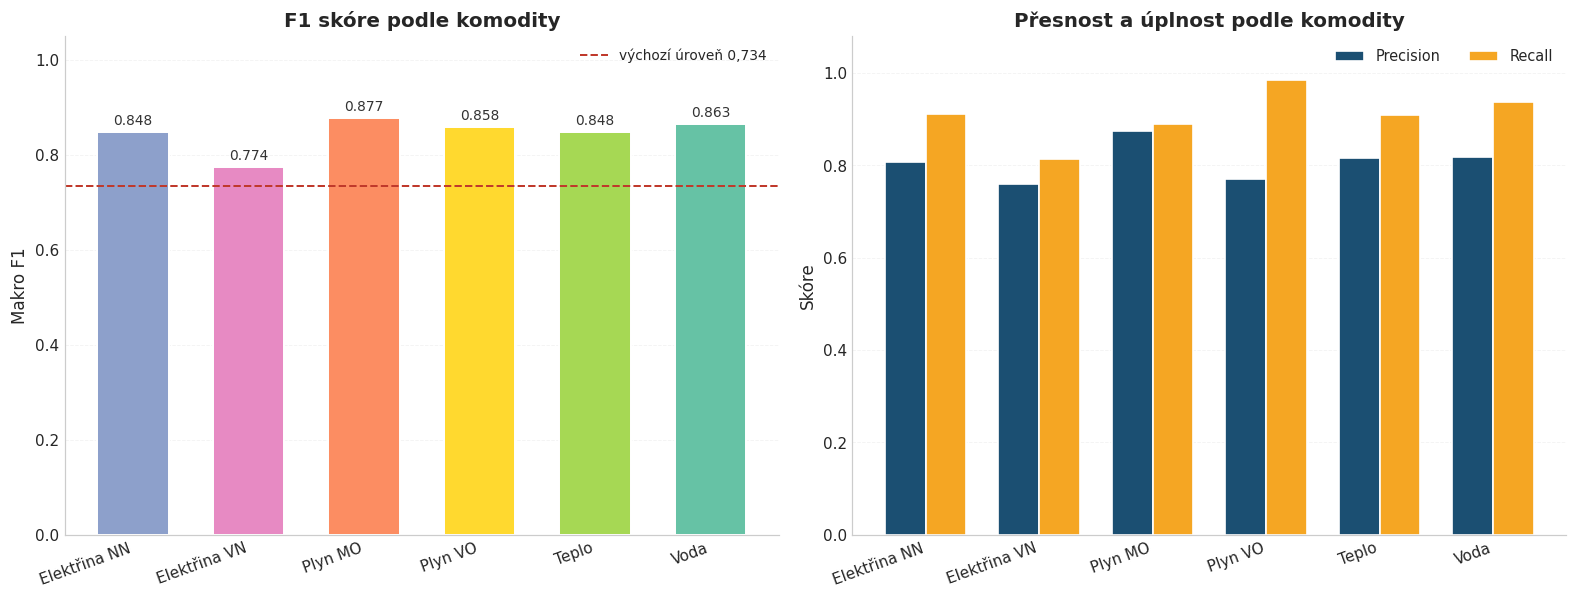

,F1,Precision,Recall,N
commodity,,,,
Elektřina NN,0.848,0.806,0.911,320
Elektřina VN,0.774,0.758,0.813,45
Plyn MO,0.877,0.874,0.889,55
Plyn VO,0.858,0.771,0.984,23
Teplo,0.848,0.815,0.908,75
Voda,0.863,0.819,0.936,55


In [5]:
VYCHOZI_UROVEN = 0.734   # výchozí konfigurace před zapracováním zjištění z NB02–06

dle_komodity = (faktury.groupby("commodity")
                       .agg(F1=("f1", "mean"), Precision=("precision", "mean"),
                            Recall=("recall", "mean"), N=("f1", "size"))
                       .reindex(KOMODITY))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 5.6))

nazvy = [NAZVY_KOMODIT[k] for k in dle_komodity.index]
ax1.bar(nazvy, dle_komodity.F1, color=[BARVY_KOMODIT[k] for k in dle_komodity.index],
        width=0.62, edgecolor="white", linewidth=1.3)
popisky_sloupcu(ax1, fmt="{:.3f}")
ax1.axhline(VYCHOZI_UROVEN, color=PRAH, linestyle="--", linewidth=1.3,
            label=f"výchozí úroveň {VYCHOZI_UROVEN:.3f}".replace(".", ","))
ax1.set_ylim(0, 1.05)
uprav_osu(ax1, "F1 skóre podle komodity", y="Makro F1")
ax1.legend(frameon=False, fontsize=9, loc="upper right")
ax1.tick_params(axis="x", rotation=20)
for p in ax1.get_xticklabels():
    p.set_ha("right")
ax1.grid(axis="x", visible=False)

x, sirka = np.arange(len(dle_komodity)), 0.36
ax2.bar(x - sirka / 2, dle_komodity.Precision, sirka, label="Precision",
        color="#1B4F72", edgecolor="white", linewidth=1.1)
ax2.bar(x + sirka / 2, dle_komodity.Recall, sirka, label="Recall",
        color="#F5A623", edgecolor="white", linewidth=1.1)
ax2.set_xticks(x)
ax2.set_xticklabels(nazvy, rotation=20, ha="right")
ax2.set_ylim(0, 1.08)
uprav_osu(ax2, "Přesnost a úplnost podle komodity", y="Skóre")
ax2.legend(frameon=False, fontsize=9.5, ncol=2)
ax2.grid(axis="x", visible=False)

fig.tight_layout()
plt.show()

display(tabulka(dle_komodity.rename(index=NAZVY_KOMODIT).round(3)))

> **Zjištění.** Nejlepšího výsledku dosahuje Plyn MO (F1 0,877), nejslabší je
> Elektřina VN (0,774) — stále nad výchozí úrovní, ale s odstupem od ostatních
> komodit. Všech šest komodit zůstává nad akceptačním prahem.
>
> U všech komodit je **úplnost vyšší než přesnost** — systém tedy častěji vyplní
> pole špatnou hodnotou, než aby ho vynechal. Rozdíl je nejvýraznější u Plynu VO
> (0,77 vůči 0,98), nejmenší u Plynu MO, kde jsou obě metriky vyrovnané.

## 7.4 Odolnost vůči kvalitě skenu (Obrázek 5.3 v práci)

Kritérium K9 požaduje, aby systém spolehlivě extrahoval alespoň základní pole
i z nejproblematičtějších dokumentů.

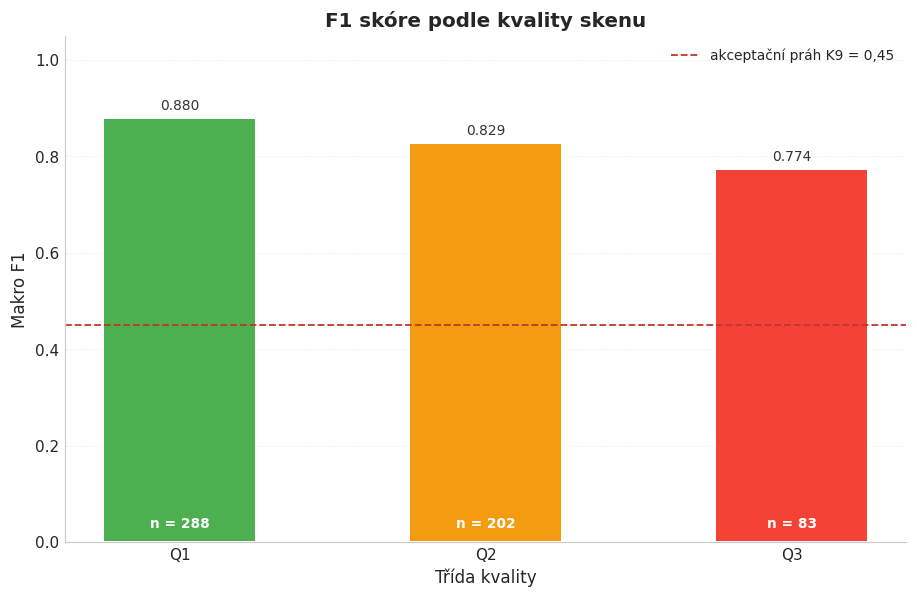

Pokles Q1 → Q3: 0.106 F1 (12.0% relativně)


In [6]:
dle_kvality = (faktury.groupby("quality")
                      .agg(F1=("f1", "mean"), N=("f1", "size")))
BARVY_TRID = {"Q1": "#4CAF50", "Q2": "#F39C12", "Q3": "#F44336"}

fig, ax = plt.subplots(figsize=(8.5, 5.6))
ax.bar(dle_kvality.index, dle_kvality.F1,
       color=[BARVY_TRID[q] for q in dle_kvality.index],
       width=0.5, edgecolor="white", linewidth=1.3)
popisky_sloupcu(ax, fmt="{:.3f}")
cara_prahu(ax, 0.45, "akceptační práh K9 = 0,45")
ax.set_ylim(0, 1.05)
uprav_osu(ax, "F1 skóre podle kvality skenu", x="Třída kvality", y="Makro F1")
ax.grid(axis="x", visible=False)
for i, (q, radek) in enumerate(dle_kvality.iterrows()):
    ax.text(i, 0.03, f"n = {int(radek.N)}", ha="center", fontsize=9, color="white",
            fontweight="600")
fig.tight_layout()
plt.show()

pokles = dle_kvality.F1.iloc[0] - dle_kvality.F1.iloc[-1]
print(f"Pokles Q1 → Q3: {pokles:.3f} F1 ({pokles / dle_kvality.F1.iloc[0]:.1%} relativně)")

> **Zjištění.** S klesající kvalitou skenu klesá i přesnost, pokles je ale **plynulý**
> — ani nejhorší skeny nezpůsobují prudký propad. Kritérium K9 je splněno s velkou
> rezervou (0,774 proti požadovaným 0,45).

## 7.5 Přesnost klíčových polí (Obrázek 5.4 v práci)

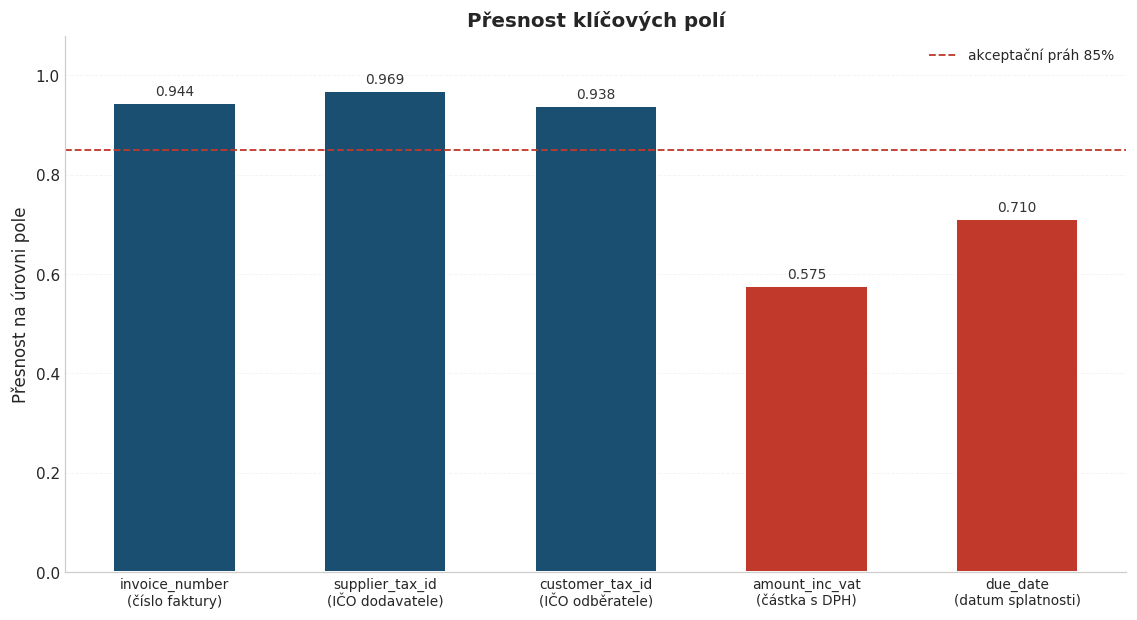

In [7]:
KLICOVA = ["invoice_number", "supplier_tax_id", "customer_tax_id",
           "amount_inc_vat", "due_date"]
NAZVY_POLI = {
    "invoice_number": "číslo faktury", "supplier_tax_id": "IČO dodavatele",
    "customer_tax_id": "IČO odběratele", "amount_inc_vat": "částka s DPH",
    "due_date": "datum splatnosti",
}
PRAH_POLE = 0.85

klicova = presnost_pole.reindex(KLICOVA)

fig, ax = plt.subplots(figsize=(10.5, 5.8))
barvy = ["#1B4F72" if v >= PRAH_POLE else "#C0392B" for v in klicova]
ax.bar([f"{p}\n({NAZVY_POLI[p]})" for p in klicova.index], klicova,
       color=barvy, width=0.58, edgecolor="white", linewidth=1.3)
popisky_sloupcu(ax, fmt="{:.3f}")
cara_prahu(ax, PRAH_POLE, f"akceptační práh {PRAH_POLE:.0%}")
ax.set_ylim(0, 1.08)
uprav_osu(ax, "Přesnost klíčových polí", y="Přesnost na úrovni pole")
ax.tick_params(axis="x", labelsize=9)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 7.6 Přesnost všech polí podle komodity (Obrázek 5.5 v práci)

Kromě sledovaných klíčových polí systém extrahuje i řadu vedlejších číselných
údajů — například sazby za rezervovanou kapacitu nebo distribuci.

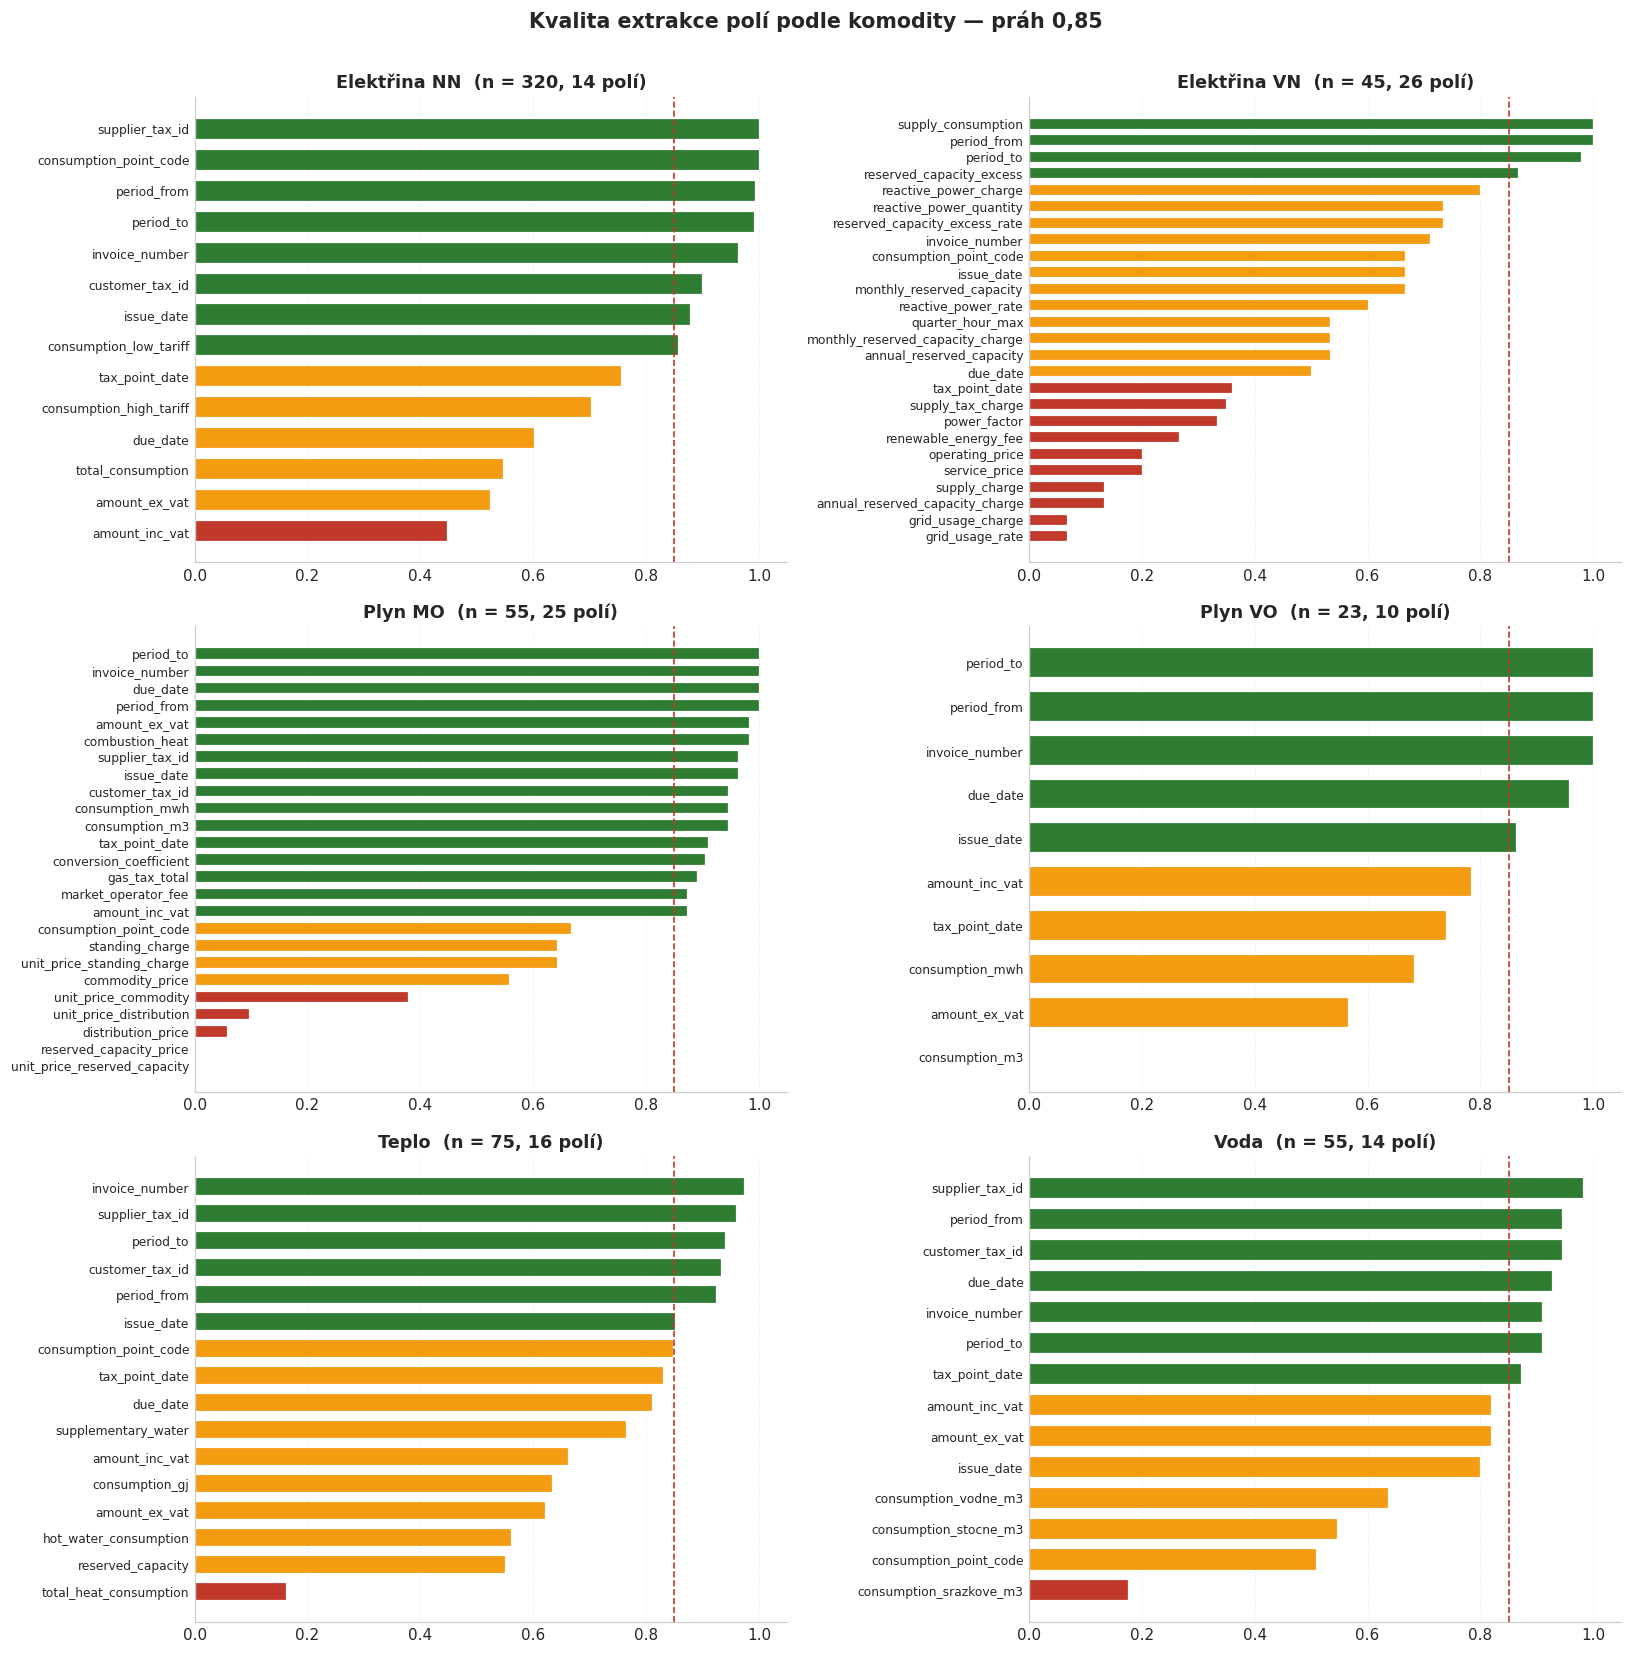

In [8]:
po_komodite = (pole.groupby(["commodity", "field"]).status
                   .apply(lambda s: (s == "tp").mean()).rename("presnost").reset_index())

fig, osy = plt.subplots(3, 2, figsize=(15, 15))
for ax, komodita in zip(osy.ravel(), KOMODITY):
    vyber = (po_komodite[po_komodite.commodity == komodita]
             .sort_values("presnost", ascending=True))
    n_faktur = int((faktury.commodity == komodita).sum())
    barvy = ["#2E7D32" if v >= PRAH_POLE else "#F39C12" if v >= 0.5 else "#C0392B"
             for v in vyber.presnost]
    ax.barh(vyber.field, vyber.presnost, color=barvy, height=0.68,
            edgecolor="white", linewidth=0.8)
    ax.axvline(PRAH_POLE, color=PRAH, linestyle="--", linewidth=1.1)
    ax.set_xlim(0, 1.05)
    ax.set_title(f"{NAZVY_KOMODIT[komodita]}  (n = {n_faktur}, {len(vyber)} polí)",
                 fontsize=11.5, fontweight="semibold")
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="y", visible=False)

fig.suptitle(f"Kvalita extrakce polí podle komodity — práh {PRAH_POLE:.2f}".replace(".", ","),
             fontsize=13.5, fontweight="semibold", y=1.001)
fig.tight_layout()
plt.show()

> **Zjištění.** Identifikační pole a data zůstávají nad prahem napříč všemi
> komoditami. Nejsložitější je Elektřina VN — z 26 polí splní práh jen 4, zbytek
> tvoří specifické tarifní položky (sazby za jalový výkon, rezervovanou kapacitu),
> u nichž kvalita extrakce klesá k 0,07–0,13.
>
> Pozoruhodné je, že přesnost u ceny za rezervovanou kapacitu klesá na nulu
> nezávisle na sobě hned u dvou komodit (Elektřina VN i Plyn MO). Jde tedy
> o systematický, nikoli náhodný problém — tento údaj se na fakturách vyskytuje
> jen zřídka nebo v nejednotném formátu.

## 7.7 Latence zpracování (Obrázek 5.6 v práci)

Rozpad doby zpracování na hlavní a záložní cestu ukazuje, kolik času spotřebuje
který krok a jakou režii přináší eskalace na Vision-LLM.

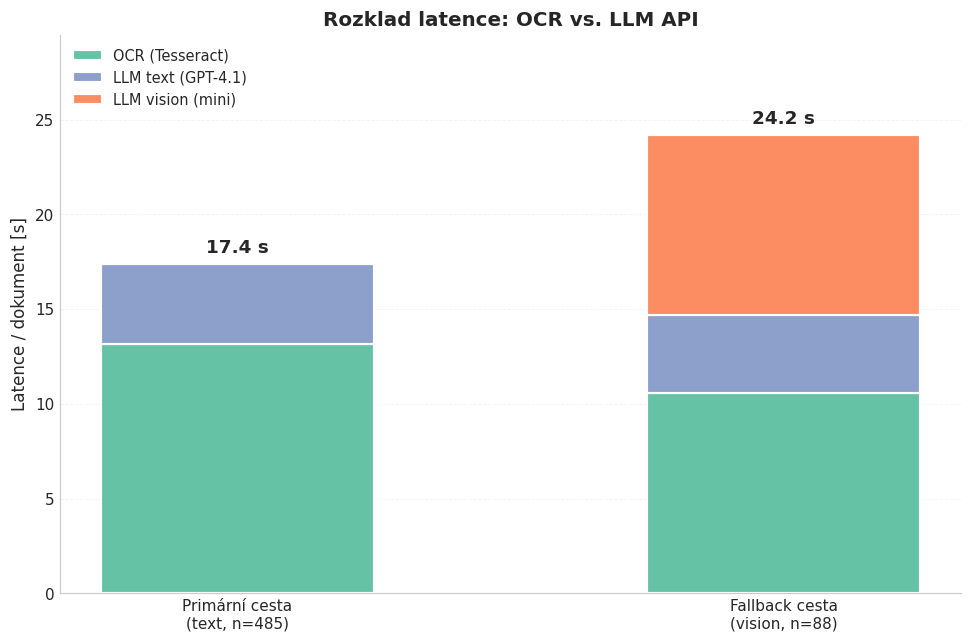

Nejpomalejší cesta (24.2 s) zůstává hluboko pod limitem 60 s podle kritéria K8.


,OCR (Tesseract),LLM text (GPT-4.1),LLM vision (mini)
"Primární cesta (text, n=485)",13.100,4.200,0.000
"Fallback cesta (vision, n=88)",10.600,4.100,9.500


In [9]:
hlavni = faktury[faktury.escalated == 0]
zalozni = faktury[faktury.escalated == 1]

slozky = pd.DataFrame({
    f"Primární cesta\n(text, n={len(hlavni)})": [
        hlavni.ocr_ms.mean() / 1000, hlavni.text_llm_ms.mean() / 1000, 0.0],
    f"Fallback cesta\n(vision, n={len(zalozni)})": [
        zalozni.ocr_ms.mean() / 1000, zalozni.text_llm_ms.mean() / 1000,
        zalozni.vision_llm_ms.mean() / 1000],
}, index=["OCR (Tesseract)", "LLM text (GPT-4.1)", "LLM vision (mini)"]).T

BARVY_SLOZEK = ["#66C2A5", "#8DA0CB", "#FC8D62"]

fig, ax = plt.subplots(figsize=(9, 6))
spodek = np.zeros(len(slozky))
for slozka, barva in zip(slozky.columns, BARVY_SLOZEK):
    ax.bar(slozky.index, slozky[slozka], bottom=spodek, label=slozka,
           color=barva, width=0.5, edgecolor="white", linewidth=1.4)
    spodek += slozky[slozka].to_numpy()

for x, celkem in enumerate(slozky.sum(axis=1)):
    ax.text(x, celkem + 0.4, f"{celkem:.1f} s", ha="center", va="bottom",
            fontsize=12, fontweight="700")

ax.set_ylim(0, slozky.sum(axis=1).max() * 1.22)
uprav_osu(ax, "Rozklad latence: OCR vs. LLM API", y="Latence / dokument [s]")
ax.legend(frameon=False, fontsize=9.5, loc="upper left")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

print(f"Nejpomalejší cesta ({slozky.sum(axis=1).max():.1f} s) zůstává hluboko "
      f"pod limitem 60 s podle kritéria K8.")
display(tabulka(slozky.round(1)))

## 7.8 Rozbor nesplněných kritérií

**Částka s DPH (57,5 %).** Systém částku s DPH automaticky nedopočítává ze základu
daně a sazby — takový dopočet by spoléhal na pole *základ daně*, které trpí stejnou
chybou jako částka s DPH samotná, a chybu by tak jen přenášel z jednoho pole do
druhého. Dalším krokem by měla být oprava extrakce samotného základu daně, ne
dopočet z něj.

**Datum splatnosti (71,0 %).** Většina chyb je způsobena tím, že model pole vůbec
nevyplní, nikoli záměnou za jiné datum na faktuře. Na sadě DS3 přitom stejné pole
dosahuje přesnosti o 20 procentních bodů vyšší (notebook `08`) — problém tedy
nesouvisí s tím, jak se datum splatnosti zapisuje obecně, ale spíše s konkrétními
dodavateli nebo šablonami zastoupenými v DS1.

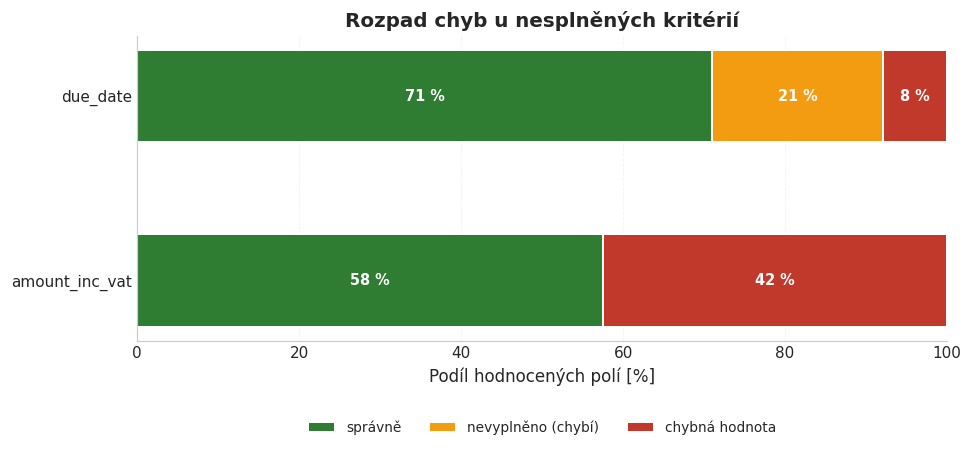

In [10]:
# Ověření: převažují u data splatnosti nevyplněná pole (fn), nebo chybné hodnoty (fp)?
rozpad = (pole[pole.field.isin(["due_date", "amount_inc_vat"])]
          .groupby(["field", "status"]).size().unstack(fill_value=0))
rozpad_pct = rozpad.div(rozpad.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 4.4))
BARVY_STAVU = {"tp": "#2E7D32", "fn": "#F39C12", "fp": "#C0392B"}
POPIS_STAVU = {"tp": "správně", "fn": "nevyplněno (chybí)", "fp": "chybná hodnota"}
levy = np.zeros(len(rozpad_pct))
for stav in ["tp", "fn", "fp"]:
    if stav not in rozpad_pct:
        continue
    hodnoty = rozpad_pct[stav].to_numpy()
    ax.barh(rozpad_pct.index, hodnoty, left=levy, color=BARVY_STAVU[stav],
            label=POPIS_STAVU[stav], height=0.5, edgecolor="white", linewidth=1.3)
    for y, (h, l) in enumerate(zip(hodnoty, levy)):
        if h >= 6:
            ax.text(l + h / 2, y, f"{h:.0f} %", ha="center", va="center",
                    color="white", fontsize=9.5, fontweight="600")
    levy += hodnoty

ax.set_xlim(0, 100)
uprav_osu(ax, "Rozpad chyb u nesplněných kritérií", x="Podíl hodnocených polí [%]")
ax.legend(frameon=False, fontsize=9, ncol=3, loc="upper center",
          bbox_to_anchor=(0.5, -0.22))
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

> **Zjištění.** U data splatnosti převažuje **nevyplněné pole** — model hodnotu
> spíše vynechá, než aby si ji vymyslel. U částky s DPH naopak převažuje **chybná
> hodnota**: model do pole zapíše základ daně místo celkové částky.

## Závěr

Na 573 reálných fakturách systém splnil **7 z 9 akceptačních kritérií**, s F1
napříč všemi komoditami i třídami kvality bez výrazně slabého místa.

| Ukazatel | Hodnota | Požadavek |
|---|---|---|
| Makro F1 | **0,85** | ≥ 0,60 ✓ |
| Strukturální platnost výstupu | **100 %** | ≥ 98 % ✓ |
| Průměrná latence | **18,4 s** | ≤ 60 s ✓ |
| Nejhorší třída kvality (Q3) | **0,774** | ≥ 0,45 ✓ |
| Cena na dokument | **$0,03** (~ 0,71 Kč) | — |

Otevřená zůstávají dvě konkrétní pole — částka s DPH a datum splatnosti. Obě mají
identifikovanou příčinu i směr další opravy, viz sekce 7.8.

Notebook `08` ověřuje, zda tyto výsledky nejsou vázané na dodavatele, které systém
dobře zná.